# Does Mean-Variance Optimization Survive Out of Sample?

*Cecilia Lo Cicero, Sara Pulidori, Alissa Sharuda, Nico Visentin*

## 0. Executive summary

**The direct ask.** Our team was hired to find the optimal weights for a tangency portfolio built from 8 core stocks: AAPL, BA, T, MGM, AMZN, IBM, TSLA and GOOG, assuming no transaction fees. The goal was to test whether a Markowitz-style approach lets a mutual fund manager beat the market. Using the full data sample (2012–2020, Section 6), the maximum-Sharpe portfolio concentrates almost entirely on three growth names: AMZN (43.5%), TSLA (29.7%) and AAPL (16.4%), with T (4.4%) and GOOG (2.5%) holding only marginal positions and the remaining stocks receiving minor weights. Over the full period, this portfolio delivered a Sharpe ratio of 1.46 and turned $1 into roughly $22, versus about $2.50 for the S&P 500 over the same window, a sharp outperformance of passive index investing.

But we have to take this number with a grain of salt. The result in Section 6 is in-sample: the optimizer was handed the full 2012–2020 return history before choosing weights, effectively knowing in advance which stocks would perform best. This is an unrealistic setting for an active fund manager. Section 7 provides a more realistic test by estimating the weights only on 2012–2015 data and applying them blindly to 2016–2020, and the results change. Based on Period 1 statistics, the expected annualized return is 37.7% and the expected Sharpe ratio 1.65. Yet the realized performance in Period 2 had a lower return, higher volatility and a Sharpe ratio of only 1.12. This is a meaningful gap between what the model expected and what it actually delivered. The strategy still beat the S&P 500 out of sample (growth of $1 of roughly 3.7× vs 1.6×), but the gap between expected and realized performance is what needs to be kept in mind. Mean-variance optimization is only as good as the inputs it gets: historical means, variances and covariances are estimates, not known constants, and small errors in those inputs can produce large, overconfident shifts in "optimal" weights.

Frequent rebalancing does not solve this issue either. The annual rebalancing experiment (Section 8: re-optimizing every year using only the prior year's data) produced a highly inconsistent year-by-year Sharpe ratio (as low as about −0.12 in weak years and as high as about 2.24 in strong ones), with a cumulative return that barely beat the S&P 500. A naive equally weighted (1/N) portfolio beat the annually re-optimized strategy, with a Sharpe ratio of 1.04 vs 0.59. We attribute this to the one-year estimation window: it is short enough that the optimizer effectively chases whichever stock had a lucky prior year, and those winners frequently mean-revert or are disrupted by new conditions the model has no way of anticipating.

One caveat is that the task does not take into account issuer concentration limits, sector limits or liquidity constraints that a real regulated fund would have to respect. As a result, the optimizer usually routes roughly 90% of the portfolio into three or four correlated tech/growth names. In practice, portfolio managers have guidelines and diversification quotas to meet, so this level of concentration would likely be prohibited.

**Bottom line.** Applying Markowitz mean-variance optimization to these stocks does identify a portfolio that would have meaningfully outperformed a passive S&P 500 investment over 2012–2020. But the framework should be taken more as a directional signal: the optimizer prefers higher-growth, higher-volatility names like AMZN and TSLA over value/defensive names like T or IBM. The gap between the in-sample Sharpe ratio of 1.46 (Section 6) and the out-of-sample 1.12 (Section 7) is the single most important number in this analysis: it is the honest price of not knowing future outcomes and the impact of unknown events.

## 1. Setup and configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
from scipy.optimize import minimize

In [2]:
# Paths
DATA_PATH = Path("../data/raw/Data_PCLab1_Stock.csv")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

# Parameters
TRADING_DAYS = 252          # annualization factor (mean x 252, covariance x 252)
N_PORTFOLIOS = 10_000       # random long-only portfolios per simulation
RANDOM_SEED = 7             # seed for the Dirichlet weight draws
RISK_FREE_RATE = 0.0        # rf = 0, so Sharpe ratio = return / volatility
SPLIT_DATE = "2016-01-01"   # Period 1: 2012-2015, Period 2: 2016-Aug 2020
N_FRONTIER_POINTS = 50      # target returns on the optimized efficient frontier


def save_fig(name, fig=None):
    """Save a figure (default: the current one) to FIG_DIR at 150 dpi."""
    (fig or plt.gcf()).savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

## 2. Data and descriptive statistics

### 2.1 Import the data, sort by date and check for missing values

In [3]:
# Load and sort by date
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values("Date").reset_index(drop=True)

# Number of stocks
stock_cols = [c for c in df.columns if c not in ["Date", "sp500"]]
print(f"Number of stocks: {len(stock_cols)}")
print(f"Stocks: {stock_cols}")

# Check for null / NA values
print(f"Null / NA values per column:\n{df.isnull().sum()}")
print(f"Are there any null values: {df.isnull().any().any()}")

Number of stocks: 8
Stocks: ['AAPL', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'TSLA', 'GOOG']
Null / NA values per column:
Date     0
AAPL     0
BA       0
T        0
MGM      0
AMZN     0
IBM      0
TSLA     0
GOOG     0
sp500    0
dtype: int64
Are there any null values: False


There are 8 stocks (AAPL, BA, T, MGM, AMZN, IBM, TSLA, GOOG) and there are no null or NA values.

### 2.2 Average level of the S&P 500

In [4]:
# Average market value of the S&P 500
avg_sp500 = df["sp500"].mean()
print(f"Average market value of S&P 500: {avg_sp500:.2f}")

Average market value of S&P 500: 2218.75


The average S&P 500 level over the sample period is 2218.75. The index rose steadily from around 1295 in 2012 to over 3200 by mid-2020; this average reflects the overall upward trend of the period rather than a stable equilibrium value. It should be read as a descriptive summary statistic, not as an indication of typical short-term index behavior.

### 2.3 Minimum dispersion in dollar value

In [5]:
# Compute the covariance matrix of prices for every stock AND the S&P 500
cov_matrix = df.iloc[:, 1:].cov()

# Compute the variances and volatilities (in $² and $; index points for the S&P 500)
variances = np.diag(cov_matrix)
volatilities = np.sqrt(np.diag(cov_matrix))

# Tabulate the dispersion of each series
dispersion_table = pd.DataFrame({
    'Stock': cov_matrix.columns,
    'Variance ($²)': variances,
    'Volatility ($)': volatilities
})

dispersion_table.sort_values('Volatility ($)')

,Stock,Variance ($²),Volatility ($)
2,T,10.287991,3.207490
3,MGM,48.495166,6.963847
5,IBM,653.412664,25.561938
0,AAPL,5016.549110,70.827601
1,BA,10749.249190,103.678586
6,TSLA,44515.937383,210.988003
7,GOOG,111855.502794,334.448057
8,sp500,288714.638185,537.321727
4,AMZN,486979.137239,697.838905


AT&T (T) has the minimum dispersion, with a standard deviation of only $3.21.

### 2.4 Maximum price of Amazon

In [6]:
# Maximum price for Amazon (AMZN)
max_amzn_price = df["AMZN"].max()
max_amzn_date = df.loc[df["AMZN"].idxmax(), "Date"].date()

print(f"Maximum Amazon (AMZN) price: ${max_amzn_price:.2f}")
print(f"Date it occurred: {max_amzn_date}")

Maximum Amazon (AMZN) price: $3225.00
Date it occurred: 2020-08-06


AMZN's maximum price ($3225.00) occurred on 2020-08-06, near the peak of the pandemic-driven rally in e-commerce and tech stocks. This represents roughly an 18× increase from AMZN's price at the start of the sample (around $176 in January 2012), reflecting both AMZN's long-run growth and a short-term demand shock from the 2020 lockdowns.

## 3. Price dynamics

### 3.1 Raw prices

Raw stock and S&P 500 index prices from January 2012 to August 2020.

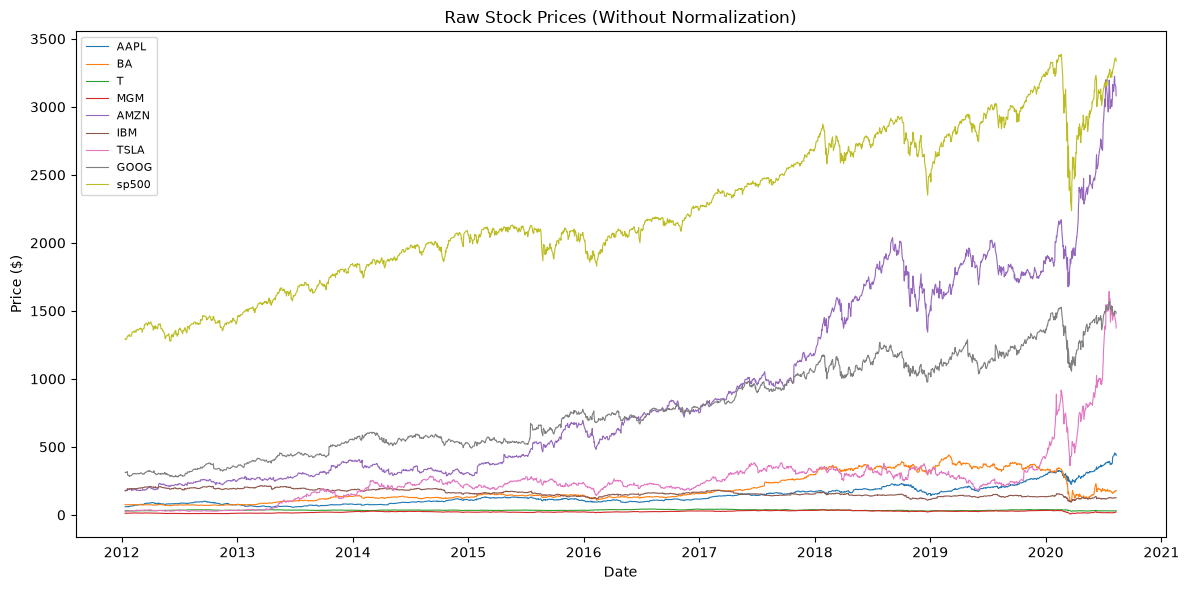

In [7]:
def plot_prices(df):
    # All columns except 'Date' are prices to plot
    cols_to_plot = [c for c in df.columns if c != "Date"]

    plt.figure(figsize=(12, 6))

    for col in cols_to_plot:
        plt.plot(df["Date"], df[col], label=col, linewidth=0.8)

    plt.title("Raw Stock Prices (Without Normalization)")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    save_fig("01_raw_prices.png")
    plt.show()

plot_prices(df)

Plotting raw dollar prices on one axis compresses low-priced stocks (T, MGM, IBM) near zero, while the S&P 500 and AMZN dominate the scale. All series drop sharply together in March 2020 (COVID), a sign of market-wide systematic risk, while BA's earlier, isolated decline (737 MAX grounding, 2019) reflects idiosyncratic, company-specific risk instead. AMZN, AAPL and TSLA recover quickly past their pre-crash highs (×1.42, ×1.34 and ×1.50 relative to their February 2020 peaks), driven by the consumption trends of the stay-at-home period, whereas GOOG ends the sample still 3% below its February 2020 peak and BA and T stay depressed much longer.

### 3.2 Normalized prices

**The idea:** divide every series by its price on the first day (2012-01-12), so that every stock and the index start at 1.0 and their growth trajectories can be compared directly.

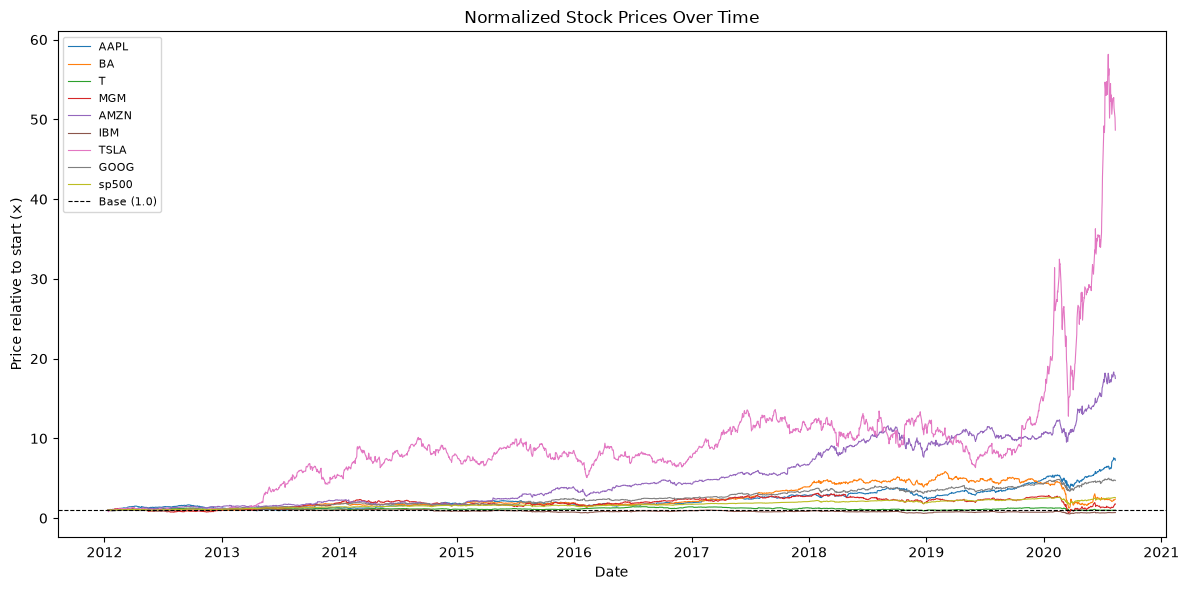

Normalized price at the end of the sample:
TSLA     48.65
AMZN     17.51
AAPL      7.27
GOOG      4.72
sp500     2.57
BA        2.39
MGM       1.77
T         1.00
IBM       0.70


In [8]:
def normalize(df):
    # Keep Date out of the division, normalize only the price columns
    cols = [c for c in df.columns if c != "Date"]
    norm = df.copy()
    norm[cols] = df[cols] / df[cols].iloc[0]
    return norm

# Apply the normalization function to our dataframe
df_norm = normalize(df)

def plot_normalized_prices(df_norm):
    cols_to_plot = [c for c in df_norm.columns if c != "Date"]
    plt.figure(figsize=(12, 6))

    for col in cols_to_plot:
        plt.plot(df_norm["Date"], df_norm[col], label=col, linewidth=0.8)

    # Reference line at 1.0 — anything above means positive return from start
    plt.axhline(y=1.0, color="black", linestyle="--", linewidth=0.8, label="Base (1.0)")

    plt.title("Normalized Stock Prices Over Time")
    plt.xlabel("Date")
    plt.ylabel("Price relative to start (×)")
    plt.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    save_fig("02_normalized_prices.png")
    plt.show()

plot_normalized_prices(df_norm)

# Value of $1 invested on the first day, at the end of the sample
print("Normalized price at the end of the sample:")
print(df_norm.drop(columns="Date").iloc[-1].sort_values(ascending=False).round(2).to_string())

Four stocks outperform the S&P 500: by August 2020 the index sits directly below TSLA, AMZN, AAPL and GOOG, so investing in several individual tech stocks would have beaten a passive index investment over this window. The other four lagged it: BA and MGM finished below the index, T was essentially flat, and IBM actually destroyed value, ending at 0.70× its starting price (−30%), the only series to close below the base line.

This shows that reward for risk is not uniform. AMZN and TSLA, the two largest cumulative gainers here, also had among the highest dollar dispersions measured in Section 2.3 ($697.84 and $210.99, with GOOG in between at $334.45).

## 4. Daily returns

In [9]:
def calculate_daily_returns(data, stock_columns):
    """Computes the daily returns (in %) of every stock"""
    # Explicit loop required by the original brief. Equivalent to
    # data[stock_columns].pct_change().fillna(0) * 100
    returns = pd.DataFrame()
    returns['Date'] = data['Date']

    for stock in stock_columns:
        stock_returns = []

        for i in range(len(data)):
            if i == 0:
                stock_returns.append(0)
            else:
                today_price = data[stock].iloc[i]
                yesterday_price = data[stock].iloc[i-1]
                daily_return = ((today_price - yesterday_price) / yesterday_price)*100
                stock_returns.append(daily_return)

        returns[stock] = stock_returns

    return returns

In [10]:
df_returns = calculate_daily_returns(df, stock_cols + ['sp500'])

# Quick check: first row should be 0, second row should have values
print("First 3 rows of returns (%):")
print(df_returns.head(3).round({c: 4 for c in stock_cols + ['sp500']}))

# Summary statistics of daily returns
print("\nSummary statistics (daily returns, %):")
print(df_returns.drop(columns="Date").describe().round(4))

First 3 rows of returns (%):
        Date    AAPL      BA       T     MGM    AMZN     IBM     TSLA    GOOG  \
0 2012-01-12  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   0.0000  0.0000   
1 2012-01-13 -0.3749 -1.2051 -0.1660  1.8137  1.4153 -0.7699 -19.3274 -0.7385   
2 2012-01-17  1.1648  0.8579  0.5986 -0.8097  1.8159  0.4689  16.7179  0.5744   

    sp500  
0  0.0000  
1 -0.4948  
2  0.3553  

Summary statistics (daily returns, %):
            AAPL         BA          T        MGM       AMZN        IBM  \
count  2159.0000  2159.0000  2159.0000  2159.0000  2159.0000  2159.0000   
mean      0.1077     0.0659     0.0082     0.0647     0.1511    -0.0061   
std       1.7758     2.2598     1.2649     2.7466     1.9278     1.4310   
min     -12.8647   -23.8484    -9.2410   -33.6140   -10.9972   -12.8507   
25%      -0.6924    -0.7841    -0.5496    -1.1097    -0.7589    -0.6263   
50%       0.0811     0.0780     0.0595     0.1083     0.1163     0.0213   
75%       1.0019     0.9465     0

- Row 0 (2012-01-12) is all 0 by construction, because there is no previous day to compare to.
- Row 1 (2012-01-13) shows the first real returns. For example, TSLA shows −19.327, meaning Tesla fell 19.3% in a single day.

> **Note on the first day.** The first day's return is set to 0 rather than dropped. This adds one zero observation out of 2,159 daily returns and has a negligible effect on the means, volatilities and correlations used below.

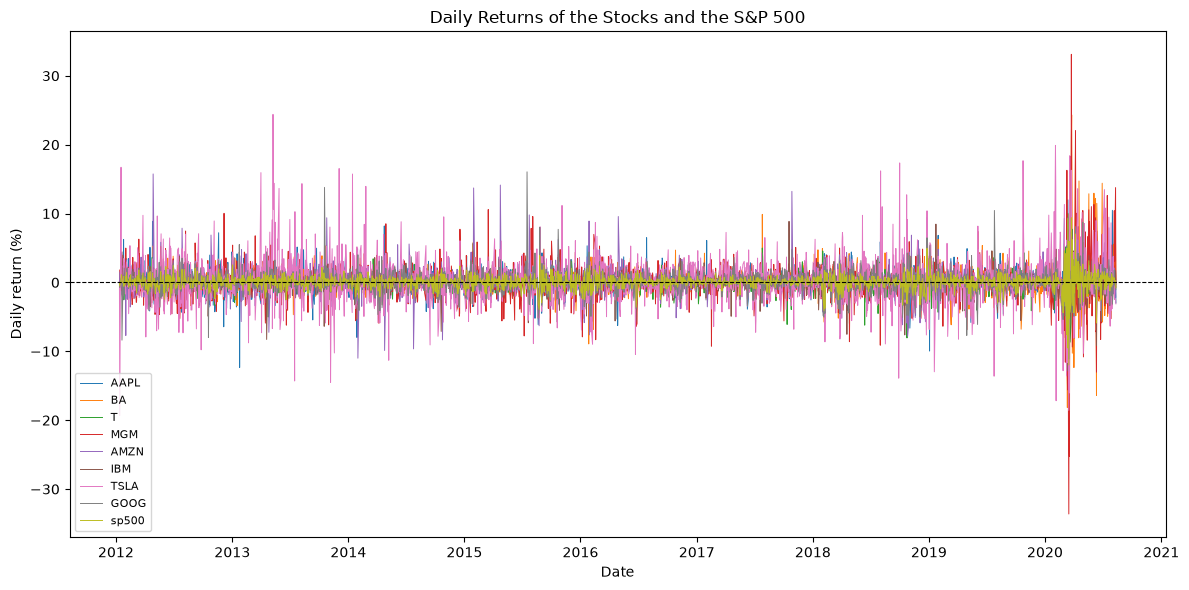

In [11]:
def plot_dataframe(data, columns, title, ylabel, xlabel='Date', fig_name=None):
    plt.figure(figsize=(12, 6))

    for col in columns:
        plt.plot(data[xlabel], data[col], label=col, linewidth=0.7)

    # Reference line at 0 — above means gain, below means loss that day
    plt.axhline(y=0, color="black", linestyle="--", linewidth=0.8)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(loc="lower left", fontsize=8)
    plt.tight_layout()
    if fig_name:
        save_fig(fig_name)
    plt.show()

plot_dataframe(data=df_returns, columns=stock_cols + ['sp500'], title='Daily Returns of the Stocks and the S&P 500',
               ylabel='Daily return (%)', fig_name="03_daily_returns.png")

In Section 2.3, MGM had one of the lowest dollar-price dispersions (std ≈ $6.96), because it traded in the $12–30 range. But computed properly as percentage daily returns, MGM has one of the highest volatilities (std ≈ 2.75%), above AAPL (1.78%) and AMZN (1.93%). Dollar-level dispersion conflates price scale with actual risk, while percentage returns are the right way to compare volatility across stocks.

In the daily-returns plot, the visible widening of the "noise band" around early 2020 across every series is the return-space counterpart of the COVID price crash seen in Section 3.1. It is a clear illustration that volatility clusters in time (calm periods vs. crisis periods), a well-known stylized fact of financial returns.

## 5. Correlations and return distributions

### 5.1 Correlation matrix of daily returns

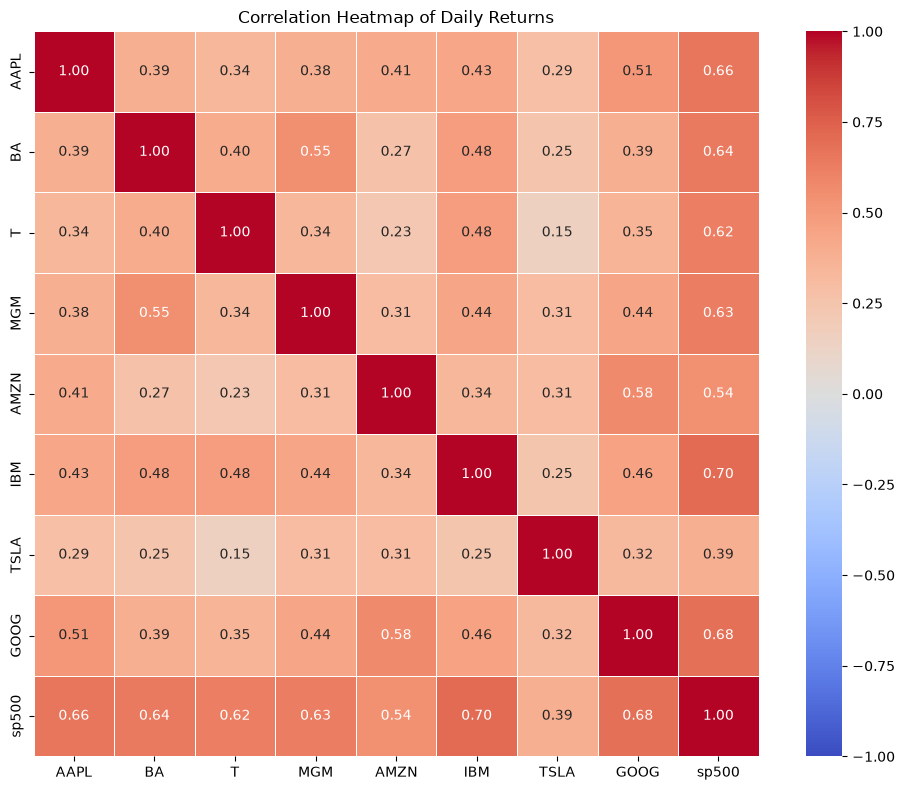

In [12]:
corr_matrix = df_returns.drop(columns="Date").corr()

# Heatmap colors:
# - Dark red / warm colors -> high positive correlation (move together)
# - Dark blue / cool colors -> negative correlation (move opposite)
# - White / neutral -> near zero (move independently)
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,          # print the correlation number inside each cell
    fmt=".2f",           # round to 2 decimal places
    cmap="coolwarm",     # red = positive, blue = negative
    vmin=-1, vmax=1,     # fix the color scale between -1 and 1
    linewidths=0.5,      # add grid lines between cells
    square=True          # make each cell square shaped
)

plt.title("Correlation Heatmap of Daily Returns")
plt.tight_layout()
save_fig("04_return_correlation_heatmap.png")
plt.show()

### 5.2 Correlations with the S&P 500 and selected pairs

In [13]:
# Correlation of each stock with the S&P 500
# (drop sp500 itself: its correlation with itself is 1.0)
sp500_corr = corr_matrix["sp500"].drop("sp500")

# Sort descending and take the top 2
top2 = sp500_corr.sort_values(ascending=False).head(2)

print("\nCorrelations with S&P 500:")
print(sp500_corr.sort_values(ascending=False))
print(f"\nTop 2 stocks most correlated with S&P 500:")
print(top2)

# Correlations of Amazon and Boeing, and of MGM and Boeing
amzn_ba = df_returns[['AMZN']].corrwith(df_returns['BA'])
mgm_ba = df_returns[['MGM']].corrwith(df_returns['BA'])
print(amzn_ba)
print(mgm_ba)


Correlations with S&P 500:
IBM     0.703935
GOOG    0.684572
AAPL    0.657321
BA      0.641826
MGM     0.631449
T       0.617463
AMZN    0.539560
TSLA    0.387921
Name: sp500, dtype: float64

Top 2 stocks most correlated with S&P 500:
IBM     0.703935
GOOG    0.684572
Name: sp500, dtype: float64
AMZN    0.267466
dtype: float64
MGM    0.554229
dtype: float64


**Heatmap.** All correlations are positive (cells are red and none are blue), indicating that all stocks tend to move in the same direction as the market. Part of this shared component is systematic risk.

**Correlations with the S&P 500.** The two stocks most correlated with the S&P 500 are IBM (0.70) and GOOG (0.68). This makes sense because both are large diversified companies whose revenues track the broad economy (IBM: enterprise technology spread across many sectors; GOOG: advertising revenue that depends on overall economic activity).

**AMZN and BA.** The correlation of 0.27 is relatively low. This can be explained by the fact that the companies operate in different industries with different business cycles. This is what we typically look for when diversifying a portfolio: a combination of low-correlation assets helps reduce portfolio variance. From the portfolio variance formula:

$$\sigma^2_p = \sum_i \sum_j w_i w_j \sigma_{ij}$$

where the covariance between two assets is $\sigma_{ij} = \rho_{ij} \sigma_i \sigma_j$. A lower $\rho_{ij}$ directly shrinks the cross terms, reducing total portfolio risk.

**MGM and BA.** The correlation of 0.55 is relatively high. Since the two companies do not operate in the same industry, this can be explained by the fact that both are highly sensitive to the economic cycle: in a strong economy people travel more, which is good for airlines (and hence aircraft makers) and for MGM's Las Vegas revenues, while in a recession both drop together. This is a macro/cyclical co-movement (systematic risk), not an industry co-movement.

### 5.3 Distribution of daily returns

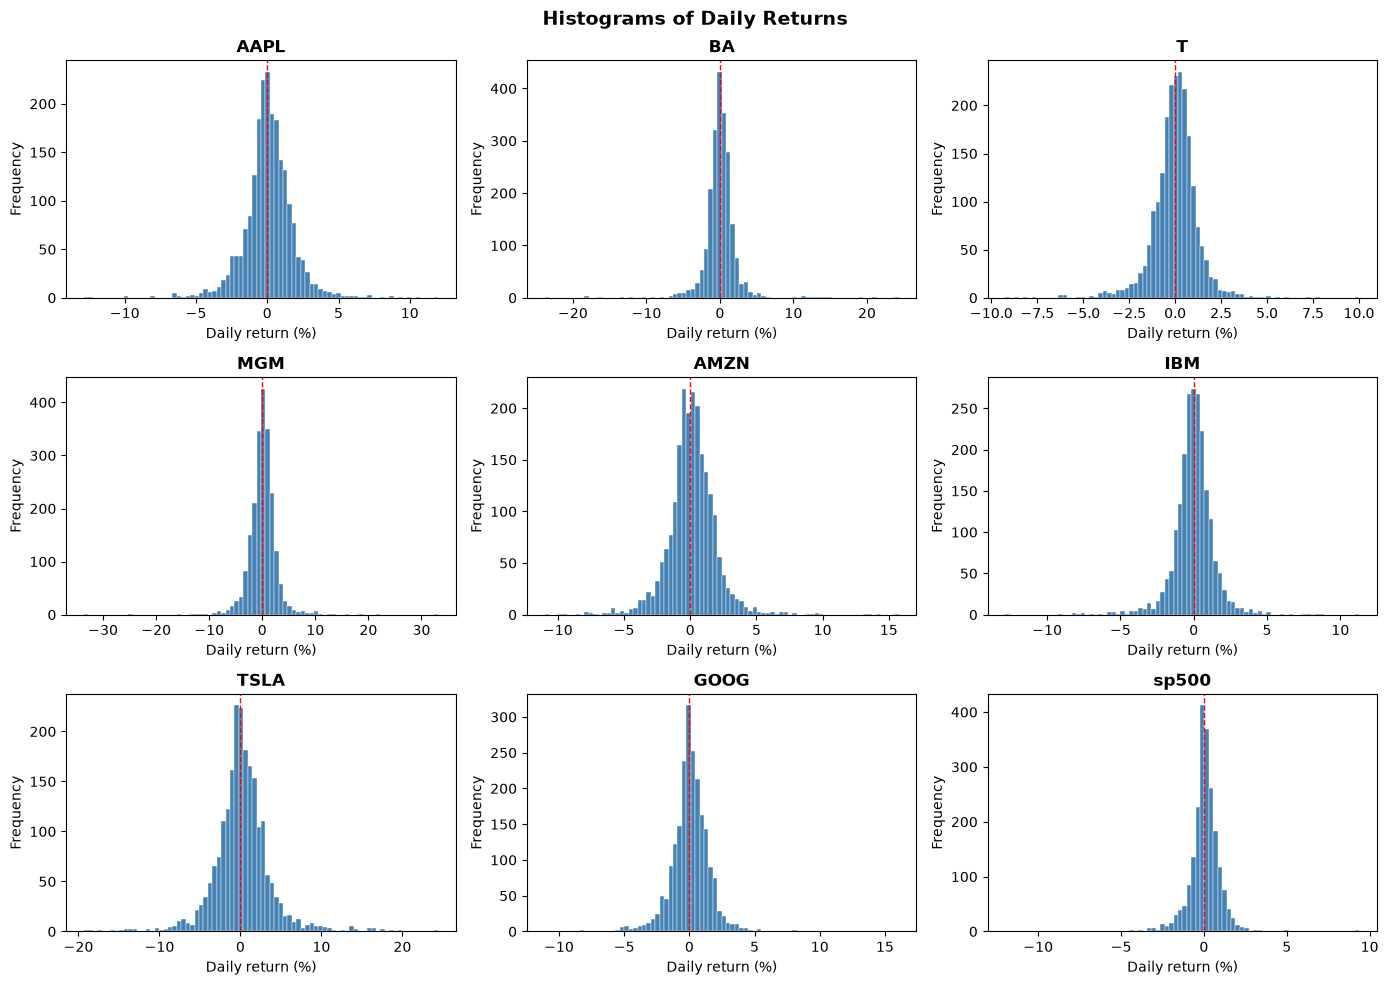

In [14]:
# - x-axis: the daily return in % (e.g. -5 means -5% that day)
# - y-axis: how many days had a return in that range
# This shows the shape of returns: are they symmetric, and are there extreme days?

def plot_histograms(df_returns):
    # Get all columns except Date
    cols = [c for c in df_returns.columns if c != "Date"]

    # Set up a grid of subplots: 3 rows x 3 columns = 9 panels (one per asset)
    fig, axes = plt.subplots(3, 3, figsize=(14, 10))

    # Flatten the 2D array of axes into a 1D list for easy looping
    axes = axes.flatten()

    # Loop through each stock and plot its histogram
    for i, col in enumerate(cols):

        axes[i].hist(
            df_returns[col],
            bins=80,                   # number of bars in the histogram
            color="steelblue",
            edgecolor="white",
            linewidth=0.3
        )

        # Add a vertical line at 0 to separate gains from losses
        axes[i].axvline(x=0, color="red", linestyle="--", linewidth=1)

        # Title and labels for each subplot
        axes[i].set_title(col, fontweight="bold")
        axes[i].set_xlabel("Daily return (%)")
        axes[i].set_ylabel("Frequency")

    plt.suptitle("Histograms of Daily Returns", fontsize=14, fontweight="bold")
    plt.tight_layout()
    save_fig("05_return_histograms.png", fig)
    plt.show()

plot_histograms(df_returns)

### 5.4 Interactive histograms (Plotly)

In [15]:
# Load Plotly's JavaScript once so the chart renders inside the notebook
init_notebook_mode(connected=True)

def plot_interactive_histograms(df_returns):

    cols = [c for c in df_returns.columns if c != "Date"]

    fig = go.Figure()

    for col in cols:
        fig.add_trace(go.Histogram(
            x=df_returns[col],
            name=col,
            opacity=0.6,
            nbinsx=80,
            histnorm="probability density"
        ))

    fig.update_layout(
        barmode="overlay",
        title="Interactive Histograms of Daily Returns",
        xaxis_title="Daily return (%)",
        yaxis_title="Density",
        legend_title="Stock",
        width=1000,
        height=600
    )

    iplot(fig)

plot_interactive_histograms(df_returns)

> **Note:** the interactive Plotly chart above renders in Jupyter and on [nbviewer](https://nbviewer.org/github/ceciliaalocicero/markowitz-out-of-sample-test/blob/main/notebooks/markowitz_portfolio_optimization.ipynb), but not in GitHub's notebook preview. The static histograms in Section 5.3 show the same distributions.

All stock and index distributions are centered near 0 and bell-shaped, confirming that on most days returns are small. The width (volatility) varies by stock: narrow histograms indicate low daily volatility (T, IBM), while wider, flatter histograms indicate high daily volatility (TSLA, MGM).

A key observation is that all distributions have fat tails: zooming into the extremes, there are daily returns of ±5%, ±10% and even ±20% for TSLA. Under a normal distribution these events would be essentially impossible; extreme events happen more often than a Gaussian model predicts. The S&P 500 distribution is the tallest and most concentrated around 0. Because the index is composed of many stocks, it shows the effect of diversification: individual stock shocks (idiosyncratic risk) average out and what is left is mostly systematic (market) risk.

## 6. Efficient frontier and tangency portfolio

### 6.1 Simulated portfolios and the tangency portfolio

In [16]:
def simulate_portfolios(data, columns, trading_days, n_portfolios=N_PORTFOLIOS, risk_free_rate=RISK_FREE_RATE):

   results = []
   weights_record = []

   mean_returns = data[columns].mean() * trading_days
   cov_matrix = data[columns].cov() * trading_days

   np.random.seed(RANDOM_SEED)
   for _ in range(n_portfolios):

       weights = np.random.dirichlet(np.ones(len(columns)))

       port_return = np.dot(weights, mean_returns)
       port_variance = weights @ cov_matrix @ weights
       port_volatility = np.sqrt(port_variance)
       sharpe = (port_return - risk_free_rate) / port_volatility

       results.append([port_return, port_variance, port_volatility, sharpe])
       weights_record.append(weights)

   results_df = pd.DataFrame(results, columns=['Return', 'Variance', 'Volatility', 'Sharpe'])

   max_sharpe_idx = results_df['Sharpe'].idxmax()
   max_sharpe_row = results_df.loc[max_sharpe_idx]
   optimal_weights = weights_record[max_sharpe_idx]

   return results_df, optimal_weights, max_sharpe_row

results_df, optimal_weights, max_sharpe_row = simulate_portfolios(data=df_returns, columns=stock_cols, trading_days=TRADING_DAYS)

  TANGENCY PORTFOLIO (Maximum Sharpe Ratio)
  Annualized Return   : 39.89%
  Annualized Variance : 751.0623 %²
  Annualized Std Dev  : 27.41%
  Sharpe Ratio        : 1.4557

  Weights:
    AMZN : 43.5%
    TSLA : 29.7%
    AAPL : 16.4%
    T    : 4.4%
    GOOG : 2.5%
    MGM  : 2.0%
    IBM  : 1.0%
    BA   : 0.5%


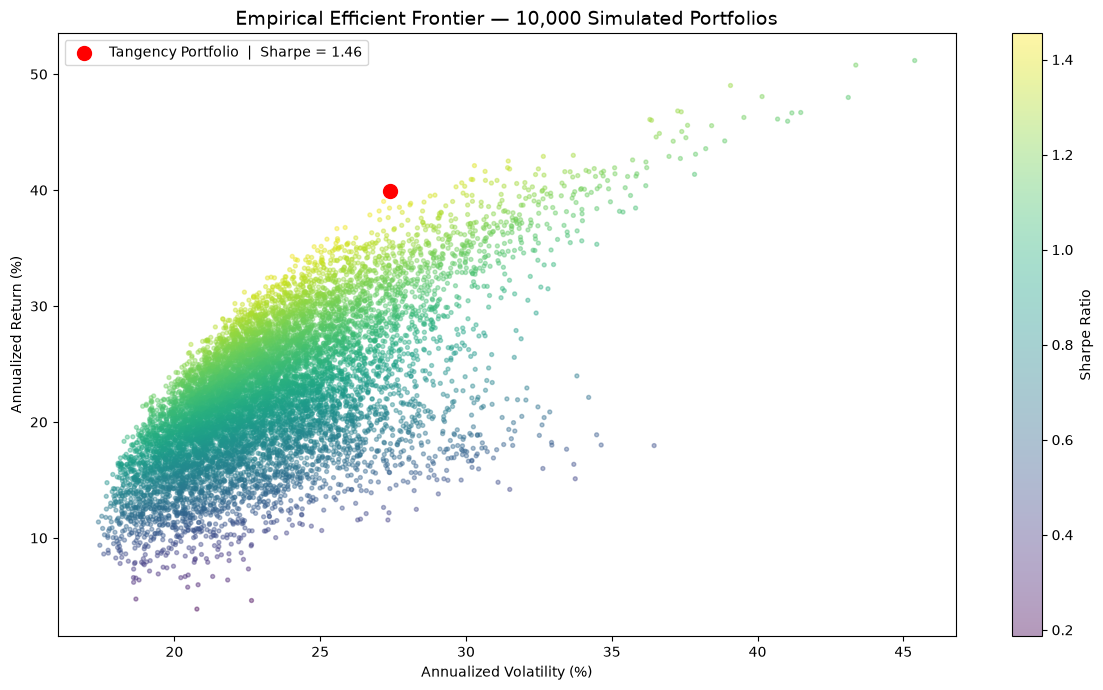

In [17]:
print("=" * 52)
print("  TANGENCY PORTFOLIO (Maximum Sharpe Ratio)")
print("=" * 52)
print(f"  Annualized Return   : {max_sharpe_row['Return']:.2f}%")
print(f"  Annualized Variance : {max_sharpe_row['Variance']:.4f} %²")
print(f"  Annualized Std Dev  : {max_sharpe_row['Volatility']:.2f}%")
print(f"  Sharpe Ratio        : {max_sharpe_row['Sharpe']:.4f}")
print("\n  Weights:")

for stock, w in sorted(zip(stock_cols, optimal_weights), key=lambda x: x[1], reverse=True):
    print(f"    {stock:5s}: {w*100:.1f}%")
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    results_df['Volatility'],
    results_df['Return'],
    c=results_df['Sharpe'],
    cmap="viridis",
    alpha=0.4,
    s=8
)
plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(
    max_sharpe_row['Volatility'],
    max_sharpe_row['Return'],
    color="red",
    marker="o",
    s=100,
    zorder=5,
    label=f"Tangency Portfolio  |  Sharpe = {max_sharpe_row['Sharpe']:.2f}"
)

plt.title("Empirical Efficient Frontier — 10,000 Simulated Portfolios", fontsize=14)
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.legend(fontsize=10)
plt.tight_layout()
save_fig("06_simulated_portfolios_tangency.png")
plt.show()

**This graph** shows 10,000 random portfolios in risk-return space, colored from purple (low Sharpe ratio) to yellow (high Sharpe ratio). The red dot is the tangency portfolio, the portfolio with the maximum Sharpe ratio (return 39.89%, volatility 27.41%, Sharpe 1.4557, with weights AMZN 43.5%, TSLA 29.7%, AAPL 16.4%, T 4.4%, GOOG 2.5%, MGM 2.0%, IBM 1.0%, BA 0.5%).

**The 10,000 portfolios do not spread uniformly but form a bullet-like shape in risk-return space**, the empirical frontier. The left/upper-left boundary of the cloud approximates the efficient frontier: for every level of risk, no simulated portfolio does better in return, so everything inside the cloud is dominated (the same return is available with less risk, or more return for the same risk). This reflects one of Markowitz's central results: not all diversified portfolios are equally good, only those on the frontier are mean-variance efficient.

**The red dot.** The tangency portfolio sits on the upper-left part of the frontier, not at the very top, because it trades off risk and return. Geometrically it is the point where the Capital Market Line (drawn from the origin, since rf = 0) is tangent to the frontier. It is the unique optimal risky portfolio for all mean-variance investors regardless of risk aversion, and it can be combined with the risk-free asset to reach any efficient point.

### 6.2 Tangency portfolio weights and growth of $1 (in-sample)

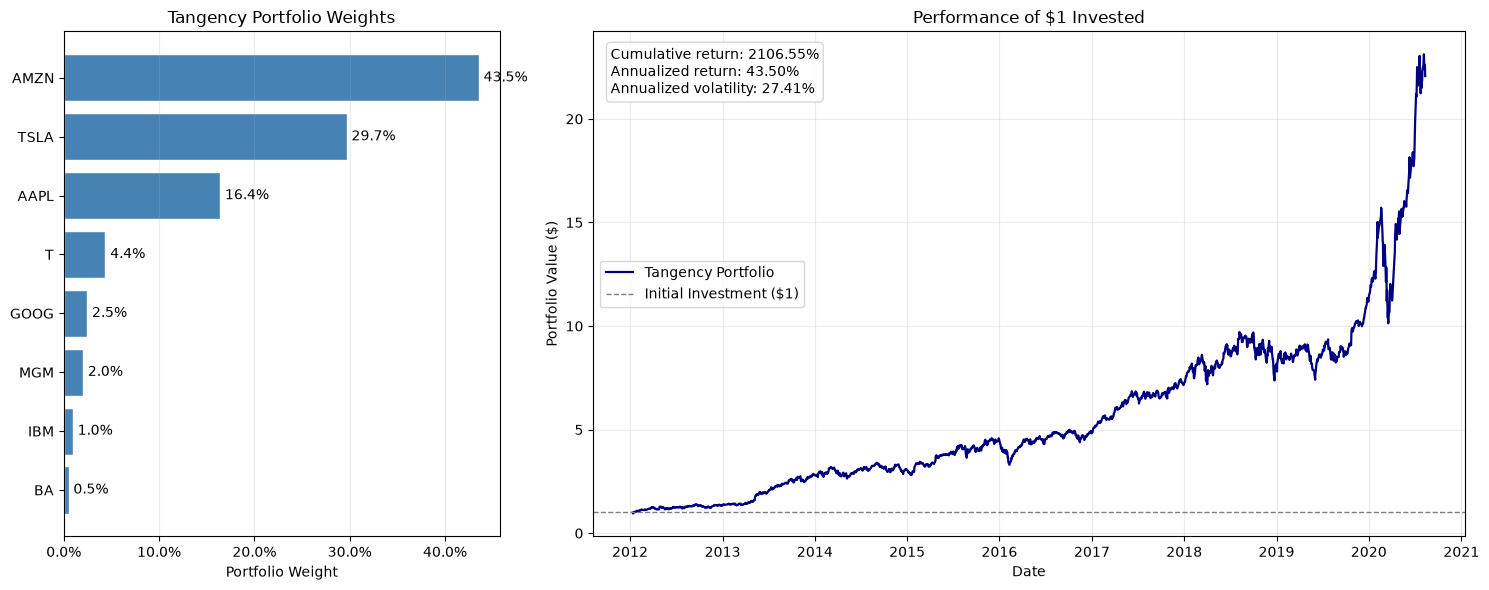

Tangency portfolio weights:
AAPL    16.41%
BA       0.52%
T        4.37%
MGM      2.03%
AMZN    43.55%
IBM      0.96%
TSLA    29.69%
GOOG     2.47%
dtype: str

Portfolio performance:
Cumulative Return        2106.55%
Annualized Return          43.50%
Annualized Volatility      27.41%
dtype: str


In [18]:
def plot_tangency_portfolio(
    daily_returns,
    tangency_weights,
    trading_days=TRADING_DAYS
):

    # Keep only the relevant return columns, indexed by date
    # df_returns is in percentage points (e.g. -1.93), so divide by 100 to get decimals for compounding
    returns = daily_returns.set_index("Date")[tangency_weights.index].copy() / 100

    # Portfolio daily returns, assuming daily rebalancing
    portfolio_daily_returns = returns.dot(tangency_weights)

    # Growth of $1 invested
    wealth_index = (1 + portfolio_daily_returns).cumprod()

    # Performance statistics
    cumulative_return = wealth_index.iloc[-1] - 1  # remove the initial dollar

    annualized_return = (
        wealth_index.iloc[-1]
        ** (trading_days / len(portfolio_daily_returns))
        - 1
    )

    annualized_volatility = (
        portfolio_daily_returns.std()
        * np.sqrt(trading_days)
    )

    # Sort weights for the bar chart
    display_weights = tangency_weights.sort_values()

    # Create both plots
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 6),
        gridspec_kw={"width_ratios": [1, 2]}
    )

    # Plot 1: Portfolio weights
    axes[0].barh(
        display_weights.index,
        display_weights.values,
        color="steelblue",
        edgecolor="white"
    )

    axes[0].set_title("Tangency Portfolio Weights")
    axes[0].set_xlabel("Portfolio Weight")
    axes[0].xaxis.set_major_formatter(
        mtick.PercentFormatter(xmax=1)
    )
    axes[0].grid(axis="x", alpha=0.25)

    # Add weight labels to the bars
    for i, weight in enumerate(display_weights.values):
        axes[0].text(
            weight + 0.005,
            i,
            f"{weight:.1%}",
            va="center"
        )

    # Plot 2: Historical performance
    axes[1].plot(
        wealth_index.index,
        wealth_index,
        color="navy",
        linewidth=1.6,
        label="Tangency Portfolio"
    )

    axes[1].axhline(
        y=1,
        color="gray",
        linestyle="--",
        linewidth=1,
        label="Initial Investment ($1)"
    )

    axes[1].set_title("Performance of $1 Invested")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Portfolio Value ($)")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    axes[1].xaxis.set_major_locator(
        mdates.YearLocator()
    )
    axes[1].xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

    # Display performance in a box
    performance_text = (
        f"Cumulative return: {cumulative_return:.2%}\n"
        f"Annualized return: {annualized_return:.2%}\n"
        f"Annualized volatility: {annualized_volatility:.2%}"
    )

    axes[1].text(
        0.02,
        0.97,
        performance_text,
        transform=axes[1].transAxes,
        va="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.9
        )
    )

    fig.tight_layout()
    save_fig("07_tangency_weights_and_performance.png", fig)
    plt.show()

    performance_summary = pd.Series({
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility
    })

    return performance_summary, portfolio_daily_returns, wealth_index


tangency_weights = pd.Series(optimal_weights, index=stock_cols)

tangency_performance, portfolio_returns, wealth = plot_tangency_portfolio(df_returns, tangency_weights, TRADING_DAYS)

print("Tangency portfolio weights:")
print(tangency_weights.apply(lambda x: f"{x:.2%}"))

print("\nPortfolio performance:")
print(tangency_performance.apply(lambda x: f"{x:.2%}"))

**The optimizer** loads up heavily on the three best-performing stocks of the period (AMZN, TSLA, AAPL). Nearly 90% of the portfolio is allocated to these three, while the other five stocks share only about 10% (the optimizer essentially dismisses them) because their risk-adjusted returns were lower. This is a concern: the optimizer overfits to historical winners and produces very concentrated portfolios.

10,000 random portfolios give a good visual representation but cannot guarantee finding the true mathematical optimum, which requires formal optimization (Section 6.3).

$1 invested in January 2012 would have grown to about $22 by August 2020, a cumulative return of 2106.55%. Growth is steady and then accelerates sharply over 2017–2020. A sharp drop followed by a fast recovery is visible in early 2020, reflecting the COVID crash and the rebound that followed until the end of the sample in August 2020. Given TSLA's 29.7% weight, the portfolio is heavily exposed to a single volatile stock, and single-asset swings dominate overall performance. (The annualized return in the chart, 43.50%, is geometric, from compounding daily returns, so it differs from the arithmetic 39.89% above.)

However, this is a pure in-sample backtest: the weights are estimated on the same data used to measure performance. It is therefore not predictive, and out of sample these weights would almost certainly underperform.

### 6.3 Optimized efficient frontier (SLSQP)

For each target return, find the long-only weights that minimize portfolio variance.

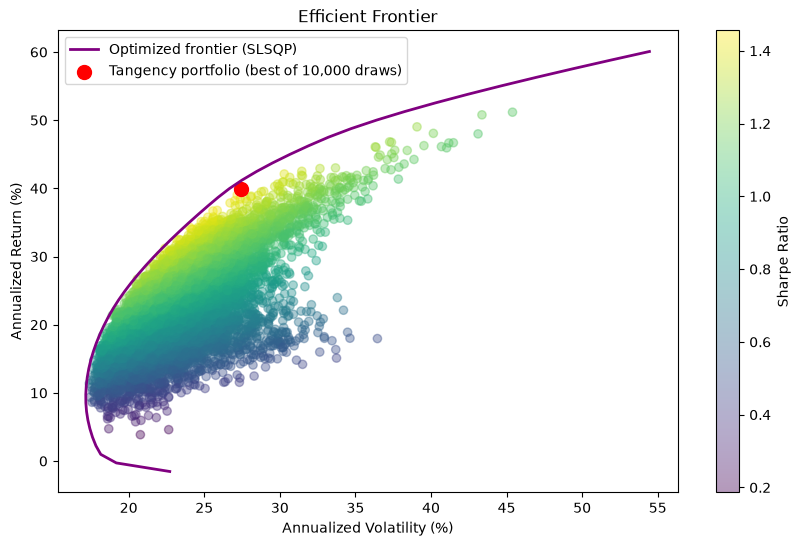

In [19]:
mean_returns = df_returns[stock_cols].mean() * TRADING_DAYS  # annualize daily mean
cov_matrix = df_returns[stock_cols].cov() * TRADING_DAYS

def portfolio_variance(weights, cov_matrix):
    return weights @ cov_matrix @ weights

def portfolio_return(weights, mean_returns):
    return np.dot(weights, mean_returns)

def efficient_frontier(mean_returns, cov_matrix, n_points=N_FRONTIER_POINTS):
    n_assets = len(mean_returns)
    target_returns = np.linspace(mean_returns.min(), mean_returns.max(), n_points)

    frontier_volatility = []
    frontier_weights = []

    bounds = tuple((0, 1) for _ in range(n_assets))
    init_guess = np.ones(n_assets) / n_assets

    for target in target_returns:
        constraints = (
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w, target=target: portfolio_return(w, mean_returns) - target}
        )

        result = minimize(portfolio_variance, init_guess, args=(cov_matrix,),
                           method='SLSQP', bounds=bounds, constraints=constraints)

        frontier_volatility.append(np.sqrt(result['fun']))
        frontier_weights.append(result['x'])

    return target_returns, frontier_volatility, frontier_weights

target_returns, frontier_vol, frontier_w = efficient_frontier(mean_returns, cov_matrix)

plt.figure(figsize=(10, 6))
plt.scatter(results_df['Volatility'], results_df['Return'], c=results_df['Sharpe'], cmap="viridis", alpha=0.4)
plt.colorbar(label='Sharpe Ratio')
plt.plot(frontier_vol, target_returns, color='purple', linewidth=2, label='Optimized frontier (SLSQP)')
plt.scatter(max_sharpe_row['Volatility'], max_sharpe_row['Return'], color='red', s=100, label='Tangency portfolio (best of 10,000 draws)')
plt.xlabel('Annualized Volatility (%)')
plt.ylabel('Annualized Return (%)')
plt.title('Efficient Frontier')
plt.legend()
save_fig("08_efficient_frontier_slsqp.png")
plt.show()

**Construction of the efficient frontier**

To construct the portfolio set, we first estimated each asset's expected annual return and the annual covariance matrix from daily historical returns. Expected returns were annualized by multiplying the average daily returns by 252, and the covariance matrix was also multiplied by 252. For any vector of portfolio weights, the expected return and variance are:

$$
E(R_p)=\mathbf{w}^{T}\boldsymbol{\mu}
$$

$$
\sigma_p^2=\mathbf{w}^{T}\boldsymbol{\Sigma}\mathbf{w}
$$

- The code selects 50 target returns between the lowest and highest individual expected asset returns.
- For each target, the SLSQP optimizer finds the portfolio with the lowest possible variance, subject to three conditions:
    - the weights must sum to one,
    - the portfolio must achieve the specified target return, and
    - every weight must remain between zero and one, to prevent short selling.

Taking the square root of the minimized variance gives the portfolio volatility plotted on the horizontal axis.

The section above the global minimum-variance portfolio is the efficient frontier, the purple line in the graph above. Portfolios on this upper section offer the highest expected return for a given level of risk: no other feasible portfolio provides a higher expected return without also increasing volatility. The lower section is part of the minimum-variance boundary but is inefficient, because it is dominated by portfolios offering higher returns for similar risk.

**Tangency portfolio**

The red dot represents the portfolio with the highest Sharpe ratio among the 10,000 simulated portfolios. It approximates the tangency portfolio, which offers the greatest expected excess return per unit of volatility:

$$
\text{Sharpe ratio}
=
\frac{E(R_p)-R_f}{\sigma_p}
$$

Because the red dot was selected from a finite random sample, it may lie slightly inside the optimized frontier rather than exactly on it. Increasing the number of simulations would generally bring the best simulated portfolio closer to the theoretical tangency point, but this is computationally inefficient and does not guarantee an exact result. A more precise approach would maximize the Sharpe ratio directly using constrained numerical optimization.

**Optimized frontier vs. simulated portfolios**

The purple line is computed by minimizing variance for each target return using constrained optimization. It forms the left boundary of the feasible set: no long-only portfolio can sit to the left of this line, and the plot confirms this, with all 10,000 random portfolios falling to its right.

The gap between the purple line and the cloud of dots illustrates an important limitation of the simulation approach: random sampling is inefficient at finding the extreme edges of the weight space. Concentrated portfolios (e.g. 90% in one stock) are extremely rare among random draws, yet these are often the ones that define the frontier. The optimizer finds them exactly, while random simulation almost never lands there. The tangency portfolio (red dot) sits slightly inside the frontier for the same reason; with millions of simulations it would converge closer to the curve.

**Key takeaway**

The two approaches are complementary. Random simulation gives an intuitive picture of the feasible portfolio set and shows how different allocations produce different combinations of risk and return. Constrained optimization traces the minimum-variance boundary precisely and identifies the portfolios that make the most efficient use of risk. Both agree on the overall shape and confirm that the best risk-return trade-offs lie along the upper-left boundary of the cloud.

The graph supports the central idea of Markowitz theory: diversification is not simply about holding many assets, but about combining assets according to their expected returns, volatilities and correlations.

## 7. Out-of-sample test (2012–2015 → 2016–2020)

### 7.1 Tangency portfolios by period

In [20]:
period_1 = df_returns[(df_returns['Date'] >= '2012-01-01') & (df_returns['Date'] < SPLIT_DATE)]
period_2 = df_returns[df_returns['Date'] >= SPLIT_DATE]

results_per1, optimal_weights_per1, max_sharpe_row_per1 = simulate_portfolios(period_1, stock_cols, trading_days=TRADING_DAYS)
results_per2, optimal_weights_per2, max_sharpe_row_per2 = simulate_portfolios(period_2, stock_cols, trading_days=TRADING_DAYS)

In [21]:
def compare_portfolios(labels, max_sharpe_rows, weights_list, stock_cols):
    # Summary stats table
    stats = pd.DataFrame(
        {label: row[['Return', 'Variance', 'Volatility', 'Sharpe']] for label, row in zip(labels, max_sharpe_rows)}
    )

    # Weights table
    weights = pd.DataFrame(
        {label: w for label, w in zip(labels, weights_list)},
        index=stock_cols
    )
    weights.loc['Sum'] = weights.sum()

    return stats, weights

stats, weights = compare_portfolios(
    ['Period 1 (2012–2015)', 'Period 2 (2016–end)', 'Full Period'],
    [max_sharpe_row_per1, max_sharpe_row_per2, max_sharpe_row],
    [optimal_weights_per1, optimal_weights_per2, optimal_weights],
    stock_cols
)

stat_units = {'Return': 'Return (%)', 'Variance': 'Variance (%²)', 'Volatility': 'Volatility (%)'}

print("=== Portfolio Stats (annualized) ===")
print(stats.rename(index=stat_units).round(4).to_string())

print("\n=== Weights ===")
print(weights.round(4).to_string())

=== Portfolio Stats (annualized) ===
                Period 1 (2012–2015)  Period 2 (2016–end)  Full Period
Return (%)                   37.7276              35.6897      39.8937
Variance (%²)               523.8607             678.4382     751.0623
Volatility (%)               22.8880              26.0468      27.4055
Sharpe                        1.6484               1.3702       1.4557

=== Weights ===
      Period 1 (2012–2015)  Period 2 (2016–end)  Full Period
AAPL                0.0315               0.2286       0.1641
BA                  0.2517               0.0144       0.0052
T                   0.0350               0.0334       0.0437
MGM                 0.0328               0.0017       0.0203
AMZN                0.3742               0.6241       0.4355
IBM                 0.0069               0.0170       0.0096
TSLA                0.2432               0.0721       0.2969
GOOG                0.0246               0.0086       0.0247
Sum                 1.0000               1

We re-ran the simulation on three windows: 2012–2015, 2016–August 2020 and the full period. The results illustrate an important feature of Markowitz portfolio theory: the optimal portfolio depends heavily on the estimated expected returns and covariance matrix.

Period 2 delivered both a lower return (35.69% vs 37.73%) and a higher volatility (26.05% vs 22.89%), so the Sharpe ratio falls from 1.65 to 1.37. The substantial change in portfolio weights, especially the increased allocation to AMZN and the reduced allocations to BA and TSLA, suggests that the assets' estimated risk-return relationships changed between periods. This also demonstrates a practical limitation of mean-variance optimization: optimal weights can be unstable, because small changes in historical returns, volatilities or correlations may cause large portfolio reallocations. The full-period portfolio is a compromise across both market environments, but its lower Sharpe ratio (relative to Period 1) shows that using more data does not necessarily produce better risk-adjusted historical performance.

### 7.2 Period-1 weights applied to Period 2: expected vs. realized

In [22]:
# Apply the same portfolio (fixed weights from Period 1) to Period 2's actual data
expected_return = max_sharpe_row_per1['Return']
expected_variance = max_sharpe_row_per1['Variance']
expected_volatility = max_sharpe_row_per1['Volatility']

mean_returns_p2 = period_2[stock_cols].mean() * TRADING_DAYS
cov_matrix_p2 = period_2[stock_cols].cov() * TRADING_DAYS

realized_return = np.dot(optimal_weights_per1, mean_returns_p2)
realized_variance = optimal_weights_per1 @ cov_matrix_p2 @ optimal_weights_per1
realized_volatility = np.sqrt(realized_variance)

print("Annualized; return and volatility in %, variance in %²")
print(f"Expected (measured over Period 1):  return={expected_return:.4f}, variance={expected_variance:.4f}, volatility={expected_volatility:.4f}")
print(f"Realized (applied to Period 2):     return={realized_return:.4f}, variance={realized_variance:.4f}, volatility={realized_volatility:.4f}")

Annualized; return and volatility in %, variance in %²
Expected (measured over Period 1):  return=37.7276, variance=523.8607, volatility=22.8880
Realized (applied to Period 2):     return=32.6856, variance=845.0030, volatility=29.0689


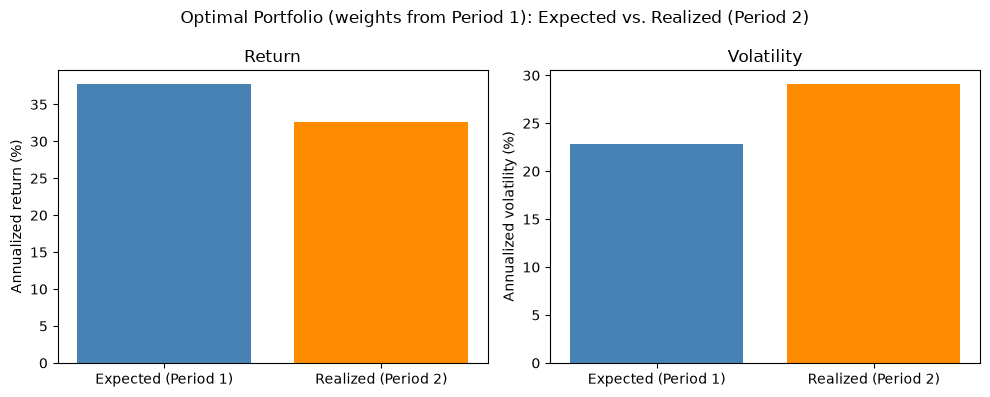

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Expected (Period 1)', 'Realized (Period 2)'],
            [expected_return, realized_return], color=['steelblue', 'darkorange'])
axes[0].set_title('Return')
axes[0].set_ylabel('Annualized return (%)')

axes[1].bar(['Expected (Period 1)', 'Realized (Period 2)'],
            [expected_volatility, realized_volatility], color=['steelblue', 'darkorange'])
axes[1].set_title('Volatility')
axes[1].set_ylabel('Annualized volatility (%)')

plt.suptitle('Optimal Portfolio (weights from Period 1): Expected vs. Realized (Period 2)')
plt.tight_layout()
save_fig("09_expected_vs_realized_bars.png", fig)
plt.show()

**Tangency portfolio weights, Period 1 (2012–2015)**

The tangency portfolio was estimated exclusively from Period 1 data. It is concentrated mainly in AMZN (37.42%), BA (25.17%) and TSLA (24.32%), which together represent approximately 87% of the portfolio. Only small weights are assigned to T, MGM, AAPL, GOOG and IBM.

In Markowitz theory, diversification depends not only on the number of assets but also on their correlations and portfolio weights. The optimizer selected a concentrated portfolio because AMZN, BA and TSLA offered the most attractive estimated combination of return, volatility and correlation during Period 1.

**Expected versus realized performance**

Based on Period 1 estimates, the portfolio was expected to generate an annualized return of 37.73% with a volatility of 22.89%. With a zero risk-free rate, this corresponds to a Sharpe ratio of approximately 1.65.

When the same weights were applied to Period 2, the realized annualized return decreased to 32.69%, while volatility increased to 29.07%. As a result, the Sharpe ratio fell to approximately 1.12. The portfolio therefore moved in an unfavorable direction: it generated a lower return while exposing the investor to greater risk.

Variance increased from 523.86 to 845.00 %², an increase of approximately 61%. This is consistent with volatility rising by about 6.18 percentage points, since variance is the square of volatility.

**Diversification and inflexibility**

The portfolio's concentration may partly explain the deterioration in out-of-sample risk. Because almost 87% of the investment was allocated to three stocks, changes in their individual volatility or correlations could have a large effect on total portfolio risk. The diversification benefits estimated during Period 1 may therefore have weakened during Period 2. Correlations are not constant and often change with market conditions, so assets that previously reduced one another's risk may not provide the same protection later.

Furthermore, fixed weights make the strategy inflexible: it cannot respond to new information, changing expected returns or changes in the covariance structure. A practical implementation could periodically re-estimate and rebalance the portfolio using a rolling window (see Section 8), although this introduces additional estimation error, turnover and transaction costs.

**Interpretation**

The difference between expected and realized performance showcases parameter uncertainty in mean-variance optimization. Markowitz assumes that expected returns and the covariance matrix estimated from historical data provide useful information about future conditions. In practice, these parameters are unstable, and relatively small estimation errors can produce concentrated portfolios and large changes in optimal weights.

The portfolio remained profitable during Period 2, but its risk-adjusted performance was substantially weaker than predicted. This does not invalidate Markowitz theory. Instead, it shows that the theoretical benefits of diversification depend on the reliability of the estimated inputs and on whether historical relationships persist.

### 7.3 Expected vs. realized in risk-return space

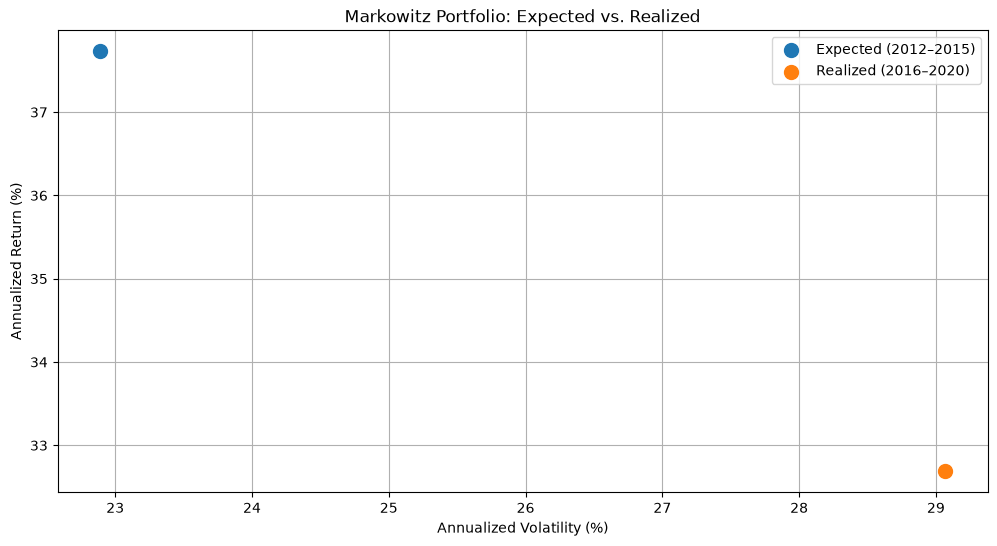

Sharpe : expected 1.648 -> realized 1.124


In [24]:
plt.figure(figsize=(12, 6))
plt.scatter(expected_volatility, expected_return, s=100, label='Expected (2012–2015)')
plt.scatter(realized_volatility, realized_return, s=100, label='Realized (2016–2020)')
plt.xlabel('Annualized Volatility (%)')
plt.ylabel('Annualized Return (%)')
plt.title('Markowitz Portfolio: Expected vs. Realized')
plt.legend()
plt.grid(True)
save_fig("10_expected_vs_realized_risk_return.png")
plt.show()

print("Sharpe : expected", round(max_sharpe_row_per1['Sharpe'], 3),
      "-> realized", round(realized_return / realized_volatility, 3))

The two points show the portfolio moving down and to the right: with the weights frozen from 2012–2015, the realized return fell from 37.73% to 32.69% while volatility rose from 22.89% to 29.07%. Less return for more risk brings the Sharpe ratio down from 1.65 to 1.12, a 32% degradation purely from applying in-sample weights out of sample.

### 7.4 Growth of $1 out of sample vs. the S&P 500

The Period-1 tangency weights are held fixed and applied to Period-2 daily returns (with daily rebalancing, the same convention as Sections 6.2 and 8), compared with the S&P 500 over the same trading days.

In [25]:
oos_daily = period_2[stock_cols] @ optimal_weights_per1
oos_growth = (1 + oos_daily / 100).prod()
oos_sp500_growth = (1 + period_2['sp500'] / 100).prod()

print(f"Growth of $1, {period_2['Date'].iloc[0].date()} to {period_2['Date'].iloc[-1].date()}:")
print(f"  Period-1 tangency weights : {oos_growth:.2f}x")
print(f"  S&P 500                   : {oos_sp500_growth:.2f}x")

Growth of $1, 2016-01-04 to 2020-08-11:
  Period-1 tangency weights : 3.70x
  S&P 500                   : 1.63x


Despite the drop in risk-adjusted performance, the Period-1 portfolio still grew $1 to about $3.7 over 2016–August 2020, versus about $1.6 for the S&P 500. In absolute terms it beat the index, largely thanks to its heavy weights in AMZN and TSLA.

## 8. Annual re-optimization vs 1/N and the S&P 500

In [26]:
# Instead of fixing weights once and holding them, re-optimize every year using only the previous year's data:
#   - estimate the tangency weights on year Y
#   - apply those weights during year Y+1 and collect the daily returns

all_years = sorted(df_returns["Date"].dt.year.unique())
estimation_years  = all_years[:-1]     # years used to estimate the weights
application_years = all_years[1:]      # years where those weights are applied

rebalanced_daily = []     # daily returns of the strategy, year after year
yearly_summary = []

for est_year, app_year in zip(estimation_years, application_years):

    ret_est = df_returns[df_returns["Date"].dt.year == est_year]
    ret_app = df_returns[df_returns["Date"].dt.year == app_year]

    # Skip incomplete years
    if len(ret_est) < 50:
        continue

    # Estimation: tangency weights based on last year only
    _, weights_year, best_row = simulate_portfolios(ret_est, stock_cols, TRADING_DAYS)

    # Application: those same weights, on the following year
    port_daily = ret_app[stock_cols] @ weights_year
    rebalanced_daily.append(port_daily)

    yearly_summary.append({
        "est_year": est_year,
        "app_year": app_year,
        "sharpe_expected": best_row['Sharpe'],
        "ann_return": port_daily.mean() * TRADING_DAYS,
        "ann_vol": port_daily.std() * np.sqrt(TRADING_DAYS),
        "top_holding": pd.Series(weights_year, index=stock_cols).idxmax(),
        "top_weight": pd.Series(weights_year, index=stock_cols).max()
    })

summary_df = pd.DataFrame(yearly_summary)
summary_df['sharpe_realized'] = summary_df['ann_return'] / summary_df['ann_vol']

print("=== ANNUAL REBALANCING — YEAR BY YEAR ===")
print(summary_df.rename(columns={'ann_return': 'ann_return (%)', 'ann_vol': 'ann_vol (%)'}).round(3).to_string(index=False))

=== ANNUAL REBALANCING — YEAR BY YEAR ===
 est_year  app_year  sharpe_expected  ann_return (%)  ann_vol (%) top_holding  top_weight  sharpe_realized
     2012      2013            1.511          31.846       14.197        AMZN       0.335            2.243
     2013      2014            4.051           3.016       17.164          BA       0.527            0.176
     2014      2015            1.514           2.695       23.997        AAPL       0.774            0.112
     2015      2016            2.300          16.139       22.289        AMZN       0.684            0.724
     2016      2017            1.622          -1.583       13.450           T       0.728           -0.118
     2017      2018            4.110          10.906       26.869          BA       0.610            0.406
     2018      2019            0.743          28.730       21.761        AMZN       0.666            1.320
     2019      2020            2.676          26.356       48.610        AAPL       0.435            0

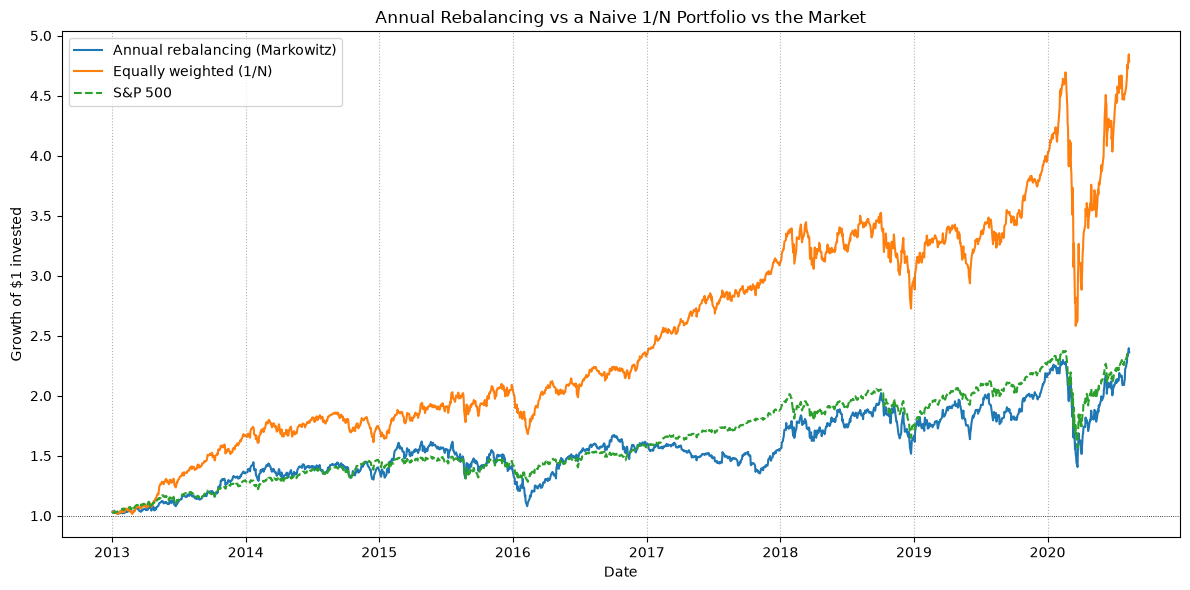

                                Ann. return (%)  Ann. volatility (%)  Sharpe  Growth of $1
Strategy                                                                                  
Annual rebalancing (Markowitz)           14.181               23.978   0.591         2.360
Equally weighted (1/N)                   23.098               22.276   1.037         4.785
S&P 500                                  12.636               17.077   0.740         2.337


In [27]:
# Overall performance: rebalanced strategy vs a naive 1/N portfolio vs the market

strategy = pd.concat(rebalanced_daily)
dates = df_returns.loc[strategy.index, "Date"]

# Equally weighted portfolio: 1/8 in each stock, no optimization at all
equal_weights = np.ones(len(stock_cols)) / len(stock_cols)
equal = df_returns.loc[strategy.index, stock_cols] @ equal_weights

market = df_returns.loc[strategy.index, "sp500"]

plt.figure(figsize=(12, 6))
plt.plot(dates, (1 + strategy / 100).cumprod(), label="Annual rebalancing (Markowitz)", linewidth=1.5)
plt.plot(dates, (1 + equal / 100).cumprod(), label="Equally weighted (1/N)", linewidth=1.5)
plt.plot(dates, (1 + market / 100).cumprod(), label="S&P 500", linewidth=1.5, linestyle="--")

# Mark each rebalancing date
for year in summary_df["app_year"]:
    plt.axvline(pd.Timestamp(f"{year}-01-01"), color="grey", linestyle=":", linewidth=0.8, alpha=0.6)

plt.axhline(y=1, color="black", linestyle=":", linewidth=0.6)
plt.title("Annual Rebalancing vs a Naive 1/N Portfolio vs the Market")
plt.xlabel("Date")
plt.ylabel("Growth of $1 invested")
plt.legend()
plt.tight_layout()
save_fig("11_annual_rebalancing_vs_1N_vs_sp500.png")
plt.show()

def performance(returns, name):
    ret = returns.mean() * TRADING_DAYS
    vol = returns.std() * np.sqrt(TRADING_DAYS)
    return {'Strategy': name, 'Ann. return (%)': ret, 'Ann. volatility (%)': vol,
            'Sharpe': ret / vol, 'Growth of $1': (1 + returns / 100).cumprod().iloc[-1]}

comparison = pd.DataFrame([
    performance(strategy, 'Annual rebalancing (Markowitz)'),
    performance(equal, 'Equally weighted (1/N)'),
    performance(market, 'S&P 500')
]).set_index('Strategy')

print(comparison.round(3).to_string())

The annually rebalanced Markowitz strategy ends slightly ahead of the S&P 500 in raw terms (14.18% vs 12.64% annualized, ×2.36 vs ×2.34), but it carries far more risk: 23.98% annualized volatility against 17.08%. Its Sharpe ratio is therefore lower (0.59 vs 0.74), meaning the small return advantage is not worth the extra risk taken.

The comparison with the equally weighted portfolio is even more telling: assigning a fixed 1/8 to each stock, with no optimization at all, returns 23.10% for 22.28% volatility (Sharpe 1.04) and turns $1 into $4.79, more than twice what the re-optimized strategy achieves. Re-estimating means and covariances on a single year of data makes the optimizer allocate between 33% and 77% of the portfolio to a single stock (above 60% in five of the eight years), and that stock keeps changing (AMZN three times, BA and AAPL twice each, T once). The estimation error therefore ends up outweighing any benefit from the optimization itself.

## 9. Limitations

- **Hindsight in stock selection.** The eight stocks are well-known names that include large ex-post winners (AMZN, TSLA, AAPL). Any strategy on this universe, including 1/N, benefits from that selection, so beating the S&P 500 here says little about skill.
- **Approximate tangency portfolio.** It is the best of 10,000 random draws, so it sits slightly inside the optimized frontier rather than exactly on it.
- **Short estimation windows.** Four years in the train/test split and one year in the annual strategy make expected-return estimates very noisy.
- **No frictions or constraints.** No transaction costs, taxes or turnover limits, no risk-free asset (rf = 0), and no concentration, sector or liquidity limits that a regulated fund would face.
- **Price returns only** (no dividends); 2020 is a partial year that includes the COVID crash.
- **Return conventions.** Most statistics use arithmetic annualization (mean × 252); the growth-of-$1 figures compound daily returns, so their annualized figures differ.
- **First-day return.** The first day's return is set to 0 rather than dropped, adding one zero observation out of 2,159 (negligible effect).

## 10. Acknowledgements and references

Team project by Cecilia Lo Cicero, Sara Pulidori, Alissa Sharuda and Nico Visentin, developed as coursework for *Finance with Big Data* (MSc, Bocconi University). The assignment framework and the price data were provided by the course; the analysis, extensions and write-up are the team's own.

- DeMiguel, V., Garlappi, L., & Uppal, R. (2009). Optimal versus naive diversification: How inefficient is the 1/N portfolio strategy? *Review of Financial Studies*, 22(5), 1915–1953.
- Markowitz, H. (1952). Portfolio selection. *Journal of Finance*, 7(1), 77–91.
- Michaud, R. O. (1989). The Markowitz optimization enigma: Is "optimized" optimal? *Financial Analysts Journal*, 45(1), 31–42.
- Sharpe, W. F. (1966). Mutual fund performance. *Journal of Business*, 39(1), 119–138.
- Tobin, J. (1958). Liquidity preference as behavior towards risk. *Review of Economic Studies*, 25(2), 65–86.